# Milestone M2 — CRAGB v1 Construction (full walkthrough)

Consolidates T2.1–T2.10 from [`M2.md`](../M2.md) into a single narrative
notebook, the same way [`00_m1_full_pipeline.ipynb`](00_m1_full_pipeline.ipynb)
does for M1. Like every other notebook in this repo (PLAN.md §6), it is
**thin** — it calls into `src/cragb`, it does not reimplement any logic.

Two steps are **not** re-run live here, and load their already-produced
artifacts instead:
- **T2.2** (LLM question drafting) — costs Groq API quota per re-run.
- **T2.6** (pooling) — needs the dense retriever indexed over the full
  200k-row corpus, which takes ~8 minutes even on the RTX 3050 GPU (see
  `PLAN.md` §14.1 for the environment note on why dense retrieval needs
  a separate venv on this machine).

Everything else re-runs live against the real, committed benchmark
files, so this notebook is a genuine re-verification of Milestone 2, not
just a report of numbers computed once elsewhere.

In [1]:
import sys
sys.path.insert(0, "../src")

import json
import pandas as pd
import matplotlib.pyplot as plt

from cragb.utils.io import load_config, resolve_path

pd.set_option("display.max_colwidth", 100)
print("cragb package importable; notebook ready")

cragb package importable; notebook ready


## T2.1 — Question taxonomy + corpus coverage check

[`cragb.bench.taxonomy`](../src/cragb/bench/taxonomy.py): loads the 7-category
taxonomy from `configs/taxonomy.yaml`, checks each category's keyword
coverage against the real `corpus_v1`, and validates the taxonomy sums to
target with every category carrying a negative quota.

In [2]:
from cragb.bench.taxonomy import load_taxonomy, check_corpus_coverage, validate_taxonomy

corpus = pd.read_parquet(resolve_path("data/processed/corpus_v1.parquet"))
taxonomy_spec = load_taxonomy("configs/taxonomy.yaml")
coverage = check_corpus_coverage(corpus, taxonomy_spec)
taxonomy_report = validate_taxonomy(taxonomy_spec, coverage)

print("PASS" if taxonomy_report.ok else "FAIL", "—", taxonomy_report.messages[0])
coverage[["n_reviews_matched", "pct_reviews_matched"]]

PASS — Taxonomy passes all checks.


,n_reviews_matched,pct_reviews_matched
category,,
fit_sizing,115636,57.82
colour_appearance,33242,16.62
fabric_quality,66973,33.49
durability,10794,5.40
defects,7944,3.97
occasion,22572,11.29
value,25447,12.72


## T2.2 — LLM-drafted candidate questions

[`cragb.generate.draft_questions`](../src/cragb/generate/draft_questions.py)
drafted ~90 candidate questions from real corpus reviews via Groq
(`llama-3.1-8b-instant`), grounded per category and over-generated 1.5x
so T2.3 had real material to curate down. **Not re-run here** — it
costs API quota; the artifact is loaded instead.

In [3]:
drafts = pd.read_json("../benchmark/cragb_draft.jsonl", lines=True)
print(f"{len(drafts)} drafted questions across {drafts['category'].nunique()} categories")
display(drafts["category"].value_counts().rename("n_drafted"))
drafts.sample(3, random_state=0)[["id", "category", "question"]]

90 drafted questions across 7 categories


category
fit_sizing           18
fabric_quality       15
colour_appearance    12
durability           12
defects              12
occasion             12
value                 9
Name: n_drafted, dtype: int64

,id,category,question
2,fit_sizing_002,fit_sizing,Do they stretch after wear?
13,fit_sizing_013,fit_sizing,Do they have a classic five-pocket styling?
53,durability_008,durability,Are the seams on these products securely stitched or prone to coming undone?


## T2.3 — Human curation to the final ~60 questions

[`cragb.bench.curate`](../src/cragb/bench/curate.py): applies automated
quality filters, enforces that every quality-passed draft has an
explicit accept/reject decision (`benchmark/curation_decisions_v1.yaml`),
merges in the authored negative probes, flags image-target categories,
and validates the result matches the taxonomy exactly.

In [4]:
from cragb.bench.curate import (
    load_drafts, load_decisions, curate as run_curation,
)

curate_cfg = load_config("configs/curate.yaml")
draft_records = load_drafts(curate_cfg["paths"]["drafts_in"])
decisions = load_decisions(curate_cfg["paths"]["decisions_in"])

curated_questions, curation_report, image_coverage = run_curation(
    drafts=draft_records,
    spec=taxonomy_spec,
    decisions=decisions,
    corpus=corpus,
    min_words=curate_cfg["quality"]["min_words"],
    max_words=curate_cfg["quality"]["max_words"],
    require_question_mark=curate_cfg["quality"]["require_question_mark"],
    min_image_coverage_pct=curate_cfg["image_target"]["min_category_coverage_pct"],
)

print("PASS" if curation_report.ok else "FAIL", "—", curation_report.messages[0])
print(f"{curation_report.total} questions, {sum(q.is_negative for q in curated_questions)} negative, "
      f"{sum(q.image_target for q in curated_questions)} image-target")

PASS — Curation matches taxonomy targets exactly.
60 questions, 11 negative, 49 image-target


## T2.4 / T2.5 — Retrievers: BM25 + dense

Both implement the same [`Retriever`](../src/cragb/retrieval/base.py)
interface. BM25 indexes the full corpus in a few seconds, so it's built
and demoed live below. The dense retriever needs `torch` +
`sentence-transformers`, which don't install in this machine's main
environment (Windows MAX_PATH issue — see `PLAN.md` §14.1); the cell
below detects that and explains rather than failing the notebook.

In [5]:
from cragb.retrieval.bm25 import BM25Retriever

bm25 = BM25Retriever()
bm25.index(corpus, text_col="text")

demo_question = curated_questions[0].question
results = bm25.search(demo_question, k=3)
print("Q:", demo_question)
for r in results:
    print(f"  rank={r.rank} score={r.score:.2f} text={corpus.loc[int(r.doc_id), 'text'][:90]!r}")

Q: Do these run true to size?
  rank=1 score=17.75 text='These do not run true to size. I am a very true Euro 39, 8.5, but these were too short.'
  rank=2 score=16.18 text='Nice looking design and pattern, however they do not run true to size.'
  rank=3 score=15.40 text='Very light material, they do not run true to size and are too short. Sent them back.'


In [6]:
try:
    from cragb.retrieval.dense import DenseRetriever
    dense = DenseRetriever(batch_size=32)
    dense.index(corpus.sample(n=300, random_state=42), text_col="text")
    results = dense.search(demo_question, k=3)
    for r in results:
        print(f"  rank={r.rank} score={r.score:.3f} doc={r.doc_id}")
except ImportError as e:
    print("Dense retriever unavailable in this kernel (expected — see PLAN.md §14.1):")
    print(" ", e)
    print("Run this notebook's kernel from C:\\venv\\cragb\\Scripts\\python.exe to exercise this cell.")

Dense retriever unavailable in this kernel (expected — see PLAN.md §14.1):
  No module named 'sentence_transformers'
Run this notebook's kernel from C:\venv\cragb\Scripts\python.exe to exercise this cell.


## T2.6 — Pooling (union of BM25 + dense top-k)

[`cragb.bench.pooling`](../src/cragb/bench/pooling.py) queried both
retrievers over the *full* corpus at k=10 for all 60 questions — an
~8-minute run dominated by dense encoding (see T2.5's note). **Not
re-run here**; the real `pools_v1.jsonl` is loaded and summarized
instead.

In [7]:
pools = pd.read_json("../benchmark/pools_v1.jsonl", lines=True)
print(f"{len(pools)} pools; size range [{pools['pool_size'].min()}, {pools['pool_size'].max()}], "
      f"mean {pools['pool_size'].mean():.2f}")
pools[["question_id", "is_negative", "pool_size", "overlap_count"]].head()

60 pools; size range [17, 20], mean 19.60


,question_id,is_negative,pool_size,overlap_count
0,fit_sizing_000,False,20,0
1,fit_sizing_001,False,20,0
2,fit_sizing_002,False,19,1
3,fit_sizing_003,False,20,0
4,fit_sizing_004,False,19,1


## T2.7 — Human relevance labeling

[`cragb.bench.label_relevance`](../src/cragb/bench/label_relevance.py):
every pooled (question, review) pair — 1,176 of them — was read and
labeled relevant or not. `validate_labels` re-checks completeness and
computes the coverage stat PLAN.md §3-E1 requires.

In [8]:
from cragb.bench.label_relevance import load_pools, load_labels, validate_labels

label_cfg = load_config("configs/labeling.yaml")
pool_records = load_pools(label_cfg["paths"]["pools_in"], label_cfg["paths"]["questions_in"])
labels = load_labels(label_cfg["paths"]["labels_in"])
label_report = validate_labels(pool_records, labels)

print("PASS" if label_report.ok else "FAIL")
print(f"{label_report.labeled_pairs}/{label_report.total_pairs} pairs labeled, "
      f"{label_report.pct_questions_with_relevant}% of questions have >=1 relevant doc")

PASS
1176/1176 pairs labeled, 96.67% of questions have >=1 relevant doc


## T2.8 — Human reference answers

[`cragb.bench.reference_answers`](../src/cragb/bench/reference_answers.py):
one grounded answer per question, citations parsed straight out of the
answer prose (`[doc_id]` markers) so they can never drift from what the
text says, and cross-checked against T2.7's relevant-doc sets.

In [9]:
from cragb.bench.reference_answers import (
    load_relevant_doc_ids, load_reference_answers, validate_reference_answers,
)
from cragb.bench.pooling import load_questions

ref_cfg = load_config("configs/reference_answers.yaml")
questions_for_answers = load_questions(ref_cfg["paths"]["questions_in"])
relevant_by_question = load_relevant_doc_ids(ref_cfg["paths"]["labels_in"])
answers = load_reference_answers(ref_cfg["paths"]["answers_in"])

answer_report = validate_reference_answers(questions_for_answers, relevant_by_question, answers)
print("PASS" if answer_report.ok else "FAIL", f"— {answer_report.answered}/{answer_report.total_questions} answered")

sample_id = questions_for_answers[0].id
print(f"\nExample [{sample_id}]:", answers[sample_id].answer[:220], "...")

PASS — 60/60 answered

Example [fit_sizing_000]: Buyers are split. A majority of reviews report these run small or not true to size -- several recommend sizing up or note returns due to a tight fit [128775][168968][6434][151873] -- while other buyers say they fit true  ...


## T2.9 — Best-evidence photo selection

[`cragb.bench.best_photo`](../src/cragb/bench/best_photo.py): for every
`image_target` question, the single most probative photo was picked
from its T2.7-relevant, image-bearing reviews — never from the raw
pool, so a surfaced photo is always real evidence, not just a retrieved
one.

In [10]:
from cragb.bench.best_photo import (
    load_image_target_questions, load_selections, validate_selections,
)

photo_cfg = load_config("configs/best_photo.yaml")
image_questions = load_image_target_questions(photo_cfg["paths"]["questions_in"])
photo_selections = load_selections(photo_cfg["paths"]["selections_in"])
photo_report = validate_selections(image_questions, relevant_by_question, corpus, photo_selections)

print("PASS" if photo_report.ok else "FAIL")
print(f"{photo_report.n_selected}/{photo_report.n_image_target_questions} image-target questions "
      f"got a real photo ({photo_report.coverage_pct}% coverage)")

PASS
37/49 image-target questions got a real photo (75.51% coverage)


## T2.10 — Assemble CRAGB v1 + datasheet + leakage guard

[`cragb.bench.assemble`](../src/cragb/bench/assemble.py): merges T2.3/
T2.7/T2.8/T2.9 into the final schema, re-derives (doesn't just trust)
every cross-task invariant, and builds the leakage-guard manifest E8
will check future fine-tune data against. Run live below — it's cheap,
so this is a real regeneration, not a cached report.

In [11]:
from cragb.bench.assemble import assemble_entries, validate_entries, compute_datasheet_stats

photo_selections_by_id = {qid: sel for qid, sel in photo_selections.items()}
entries = assemble_entries(image_questions, relevant_by_question, answers, photo_selections_by_id)
assembly_report = validate_entries(entries)
stats = compute_datasheet_stats(entries)

print("PASS" if assembly_report.ok else "FAIL", "—", assembly_report.messages[0])
stats

PASS — All cross-task invariants hold; CRAGB v1 is internally consistent.


{'total': 60,
 'by_type': {'colour_appearance': 8,
  'defects': 8,
  'durability': 8,
  'fabric_quality': 10,
  'fit_sizing': 12,
  'occasion': 8,
  'value': 6},
 'negatives_by_type': {'colour_appearance': 1,
  'defects': 2,
  'durability': 2,
  'fabric_quality': 2,
  'fit_sizing': 2,
  'occasion': 1,
  'value': 1},
 'n_negative': 11,
 'n_abstention': 2,
 'n_image_target': 49,
 'n_with_photo': 37,
 'image_coverage_pct': 75.51,
 'min_relevant_ids': 0,
 'max_relevant_ids': 20,
 'mean_relevant_ids': 13.82,
 'mean_citations_per_grounded_answer': 8.79}

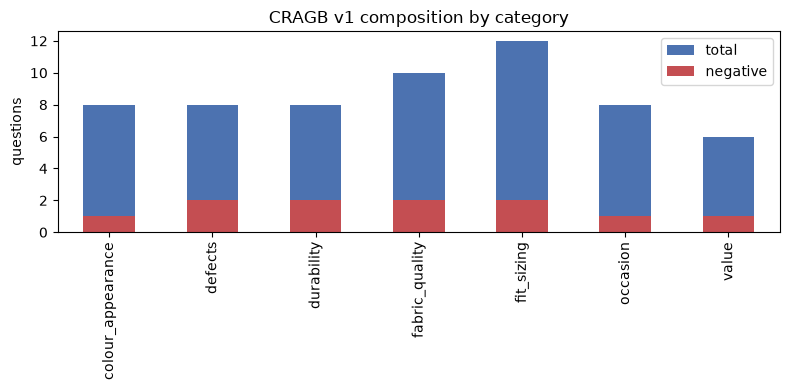

In [12]:
%matplotlib inline
by_type = pd.Series(stats["by_type"])
negatives = pd.Series(stats["negatives_by_type"]).reindex(by_type.index, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
by_type.plot.bar(ax=ax, color="#4C72B0", label="total")
negatives.plot.bar(ax=ax, color="#C44E52", label="negative")
ax.set_ylabel("questions")
ax.set_title("CRAGB v1 composition by category")
ax.legend()
plt.tight_layout()
plt.show()

### Leakage guard demo

A quick concrete check that the guard actually works: a verbatim (and a
case/whitespace-varied) copy of a real CRAGB question must be flagged;
a genuinely different question must not.

In [13]:
from cragb.bench.assemble import build_leakage_manifest, check_no_leakage

question_hashes = build_leakage_manifest(entries)
real_question = entries[0].question

leak_check = check_no_leakage(question_hashes, [
    "  " + real_question.upper() + "  ",          # should be caught (case/whitespace only)
    "Is this a completely unrelated question?",     # should NOT be caught
])
print("ok:", leak_check.ok, "| leaked:", leak_check.leaked_question_ids)

ok: False | leaked: ('fit_sizing_000',)


## Sample questions and answers

A few worked examples straight from the assembled `entries` (T2.10) —
one per category, plus one deliberate negative — showing the question,
the grounded reference answer with its inline `[doc_id]` citations, how
many reviews support it, and whether a best-evidence photo was found.

In [14]:
import textwrap

def show_entry(entry):
    tag = "NEGATIVE" if entry.is_negative else entry.type
    print(f"[{entry.id}]  ({tag})")
    print("Q:", entry.question)
    print("A:", textwrap.fill(entry.reference_answer, width=100, subsequent_indent="   "))
    print(f"   relevant reviews: {len(entry.relevant_ids)}  |  cited: {len(entry.cited_doc_ids)}  |  "
          f"abstention: {entry.is_abstention}  |  best_photo_id: {entry.best_photo_id}")
    print()

by_type = {}
for e in entries:
    by_type.setdefault(e.type, []).append(e)

# one answerable example per category
for category, group in by_type.items():
    answerable = [e for e in group if not e.is_negative]
    if answerable:
        show_entry(answerable[0])

# one negative (abstention) example, for contrast
negative_example = next(e for e in entries if e.is_negative)
show_entry(negative_example)

[fit_sizing_000]  (fit_sizing)
Q: Do these run true to size?
A: Buyers are split. A majority of reviews report these run small or not true to size -- several
   recommend sizing up or note returns due to a tight fit [128775][168968][6434][151873] -- while
   other buyers say they fit true to size with no issues [174175][114606][181526][24440]. One review
   reports the opposite, running slightly big [116140].
   relevant reviews: 20  |  cited: 9  |  abstention: False  |  best_photo_id: None

[colour_appearance_001]  (colour_appearance)
Q: Is the colour as pictured on the listing?
A: Predominantly no: most pooled reviews report the colour received did not match the listing photo --
   described as a different shade, more orange or fuschia, or an entirely wrong colour
   [134952][84010][83691][75845][44951][58790] -- though a smaller number of reviews confirm the
   colour matched as pictured [105003][168600].
   relevant reviews: 18  |  cited: 8  |  abstention: False  |  best_photo_id: 

## Summary

All ten T2.x steps re-verify clean against the committed artifacts:
taxonomy PASS, curation PASS, retrieval demoed, labeling PASS, reference
answers PASS, photo selection PASS, and the final assembly PASS with a
working leakage guard. `benchmark/cragb_v1.jsonl` (60 questions) is the
headline Milestone 2 deliverable — see
[`cragb_v1_datasheet.md`](../benchmark/cragb_v1_datasheet.md) for the
full composition writeup, and `PLAN.md` §14 for the engineering findings
that came out of building this (the Windows dense-retrieval install
issue, and 9 of 11 authored negatives turning out to have real
evidence).